# Synthetic few-shot data expansion via a diffusion model, with CLIP-based self-filtering, feeding straight into the fusion pipeline from the shared notebook.

Pipeline
--------
1. Generate synthetic support images per class two ways:
     a) text2img — new images from a class-name prompt template
        ("a photo of a {class}, ...") — adds diversity.
     b) img2img  — variations of your *real* few-shot images at a moderate
        noise strength — preserves domain-specific texture/style (important
        for anything texture-heavy) while adding pose/lighting/background
        variety.
2. Filter out low-quality / mislabeled synthetic images using CLIP zero-shot
   similarity to their intended class — keep only the top-K most confident
   generations per class. This "self-filtering" step matters: unfiltered
   generative augmentation can inject label noise that hurts more than it helps.
3. Extract CLIP + DINOv2 features for the surviving synthetic images with the
   exact same extractors used for real data.
4. Merge real + synthetic features/labels and retrain the trainable-fusion
   probe from the shared notebook, comparing accuracy with vs. without the
   synthetic expansion.

Requirements
------------
    pip install diffusers accelerate --quiet

Note: this downloads a Stable Diffusion checkpoint from the Hugging Face Hub
the first time it runs, so it needs network access and a GPU is strongly
recommended (CPU generation is very slow). If diffusers/network access isn't
available, a lightweight classical-augmentation fallback is included at the
bottom so the rest of the pipeline (filtering, feature extraction, merging)
can still be exercised.

Assumes the following already exist in scope from the shared notebook:
    clip_model, clip_processor, dino_model, dino_processor, DEVICE,
    NUM_CLASSES, CIFAR10_CLASSES, train_subset,
    train_clip, train_dino, train_labels, test_clip, test_dino, test_labels, extract_clip_features, extract_dino_features, train_probe, FusionHead, CLIP_DIM, DINO_DIM, COMMON_DIM

In [1]:
import random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as T
from torch.utils.data import Subset
from transformers import CLIPModel, CLIPProcessor, AutoModel, AutoImageProcessor
import matplotlib.pyplot as plt

try:
    from diffusers import StableDiffusionPipeline, StableDiffusionImg2ImgPipeline
    _HAS_DIFFUSERS = True
except ImportError:
    _HAS_DIFFUSERS = False
    print("diffusers not installed — run `pip install diffusers accelerate` for real generation.\n"
          "Falling back to classical-augmentation stub where used.")

In [2]:
SEED = 0
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)

CIFAR10_CLASSES = ['airplane', 'automobile', 'bird', 'cat', 'deer',
                    'dog', 'frog', 'horse', 'ship', 'truck']
NUM_CLASSES = len(CIFAR10_CLASSES)

N_SHOT = 16
N_TEST_PER_CLASS = 100
COMMON_DIM = 256

CLIP_MODEL_NAME = "openai/clip-vit-base-patch32"
DINO_MODEL_NAME = "facebook/dinov2-base"
DATA_ROOT = "./data"

print("Loading CIFAR-10...")
train_raw = torchvision.datasets.CIFAR10(root=DATA_ROOT, train=True, download=True)
test_raw = torchvision.datasets.CIFAR10(root=DATA_ROOT, train=False, download=True)


def build_fewshot_indices(dataset, n_per_class, seed=SEED):
    rng = random.Random(seed)
    by_class = {c: [] for c in range(NUM_CLASSES)}
    for idx, (_, label) in enumerate(dataset):
        by_class[label].append(idx)
    chosen = []
    for c in range(NUM_CLASSES):
        idxs = by_class[c][:]
        rng.shuffle(idxs)
        chosen.extend(idxs[:n_per_class])
    rng.shuffle(chosen)
    return chosen


train_indices = build_fewshot_indices(train_raw, N_SHOT)
test_indices = build_fewshot_indices(test_raw, N_TEST_PER_CLASS, seed=SEED + 1)
train_subset = Subset(train_raw, train_indices)
test_subset = Subset(test_raw, test_indices)
print(f"Few-shot train set: {len(train_subset)} images ({N_SHOT}-shot x {NUM_CLASSES} classes)")
print(f"Evaluation set:     {len(test_subset)} images ({N_TEST_PER_CLASS}/class x {NUM_CLASSES} classes)")

print("Loading frozen CLIP and DINOv2 backbones...")
clip_model = CLIPModel.from_pretrained(CLIP_MODEL_NAME).to(DEVICE).eval()
clip_processor = CLIPProcessor.from_pretrained(CLIP_MODEL_NAME)
for p in clip_model.parameters():
    p.requires_grad_(False)

dino_model = AutoModel.from_pretrained(DINO_MODEL_NAME).to(DEVICE).eval()
dino_processor = AutoImageProcessor.from_pretrained(DINO_MODEL_NAME)
for p in dino_model.parameters():
    p.requires_grad_(False)

CLIP_DIM = clip_model.config.projection_dim
DINO_DIM = dino_model.config.hidden_size
print("CLIP feature dim:", CLIP_DIM, " DINOv2 feature dim:", DINO_DIM)


def _unwrap_embeds(out):
    """Handles transformers versions that return a ModelOutput wrapper instead
    of a raw tensor from get_image_features()/get_text_features()."""
    if torch.is_tensor(out):
        return out
    candidate = getattr(out, "image_embeds", None)
    if candidate is None:
        candidate = getattr(out, "text_embeds", None)
    if candidate is None:
        candidate = getattr(out, "pooler_output", None)
    if candidate is None:
        candidate = out[0]
    return candidate


@torch.no_grad()
def extract_clip_features(dataset, batch_size=64):
    feats, labels = [], []
    for start in range(0, len(dataset), batch_size):
        batch = [dataset[i] for i in range(start, min(start + batch_size, len(dataset)))]
        imgs = [im for im, _ in batch]
        labs = [lb for _, lb in batch]
        inputs = clip_processor(images=imgs, return_tensors="pt").to(DEVICE)
        emb = clip_model.get_image_features(**inputs)
        emb = _unwrap_embeds(emb)
        emb = F.normalize(emb, dim=-1)
        feats.append(emb.cpu())
        labels.extend(labs)
    return torch.cat(feats, dim=0), torch.tensor(labels)


@torch.no_grad()
def extract_dino_features(dataset, batch_size=64):
    feats, labels = [], []
    for start in range(0, len(dataset), batch_size):
        batch = [dataset[i] for i in range(start, min(start + batch_size, len(dataset)))]
        imgs = [im for im, _ in batch]
        labs = [lb for _, lb in batch]
        inputs = dino_processor(images=imgs, return_tensors="pt").to(DEVICE)
        out = dino_model(**inputs)
        cls_emb = out.last_hidden_state[:, 0, :]
        cls_emb = F.normalize(cls_emb, dim=-1)
        feats.append(cls_emb.cpu())
        labels.extend(labs)
    return torch.cat(feats, dim=0), torch.tensor(labels)


print("Extracting CLIP + DINOv2 features for support/eval sets...")
train_clip, train_labels = extract_clip_features(train_subset)
test_clip, test_labels = extract_clip_features(test_subset)
train_dino, train_labels_d = extract_dino_features(train_subset)
test_dino, test_labels_d = extract_dino_features(test_subset)
assert torch.equal(train_labels, train_labels_d)
assert torch.equal(test_labels, test_labels_d)


Using device: cuda
Loading CIFAR-10...


100%|██████████| 170M/170M [00:07<00:00, 23.8MB/s]


Few-shot train set: 160 images (16-shot x 10 classes)
Evaluation set:     1000 images (100/class x 10 classes)
Loading frozen CLIP and DINOv2 backbones...


config.json:   0%|          | 0.00/4.19k [00:00<?, ?B/s]

pytorch_model.bin: reconstructing file:   0%|          |  0.00B /  605MB            

...

model.safetensors: reconstructing file:   0%|          |  0.00B /  346MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/223 [00:00<?, ?it/s]

preprocessor_config.json:   0%|          | 0.00/436 [00:00<?, ?B/s]

CLIP feature dim: 512  DINOv2 feature dim: 768
Extracting CLIP + DINOv2 features for support/eval sets...


In [3]:
# ===========================================================================
# PART B — Trainable fusion head + generic probe trainer (from the original notebook)
# ===========================================================================

class FusionHead(nn.Module):
    """Projects CLIP + DINOv2 features into a common space and fuses them."""

    def __init__(self, clip_dim, dino_dim, common_dim):
        super().__init__()
        self.proj_clip = nn.Linear(clip_dim, common_dim)
        self.proj_dino = nn.Linear(dino_dim, common_dim)
        self.fusion = nn.Sequential(
            nn.Linear(common_dim * 2, common_dim),
            nn.ReLU(),
            nn.Linear(common_dim, common_dim),
        )
        self.out_dim = common_dim
        self.clip_dim = clip_dim
        self.dino_dim = dino_dim

    def forward(self, x):
        clip_part = x[:, :self.clip_dim]
        dino_part = x[:, self.clip_dim:]
        p_clip = F.normalize(self.proj_clip(clip_part), dim=-1)
        p_dino = F.normalize(self.proj_dino(dino_part), dim=-1)
        fused = self.fusion(torch.cat([p_clip, p_dino], dim=-1))
        return fused


def train_probe(train_feats, train_labels_, test_feats, test_labels_, in_dim,
                 backbone_module=None, epochs=300, lr=1e-2, weight_decay=1e-3, verbose=False):
    train_feats = train_feats.to(DEVICE)
    test_feats = test_feats.to(DEVICE)
    train_labels_ = train_labels_.to(DEVICE)
    test_labels_ = test_labels_.to(DEVICE)

    head_in_dim = in_dim if backbone_module is None else backbone_module.out_dim
    head = nn.Linear(head_in_dim, NUM_CLASSES).to(DEVICE)

    params = list(head.parameters())
    if backbone_module is not None:
        params += list(backbone_module.parameters())
    optimizer = torch.optim.Adam(params, lr=lr, weight_decay=weight_decay)

    for epoch in range(epochs):
        head.train()
        if backbone_module is not None:
            backbone_module.train()
        optimizer.zero_grad()
        feats = backbone_module(train_feats) if backbone_module is not None else train_feats
        logits = head(feats)
        loss = F.cross_entropy(logits, train_labels_)
        loss.backward()
        optimizer.step()
        if verbose and (epoch + 1) % max(1, epochs // 5) == 0:
            print(f"  epoch {epoch+1}/{epochs}  loss={loss.item():.4f}")

    head.eval()
    if backbone_module is not None:
        backbone_module.eval()
    with torch.no_grad():
        feats = backbone_module(test_feats) if backbone_module is not None else test_feats
        preds = head(feats).argmax(dim=-1)
        acc = (preds == test_labels_).float().mean().item()
    return acc, head, backbone_module

Loading text2img pipeline (downloads checkpoint on first run)...


/usr/local/lib/python3.13/dist-packages/diffusers/utils/deprecation_utils.py:23: FutureWarning: `torch_dtype` is deprecated and will be removed in version 1.0.0. Please use `dtype` instead.
  deprecate("torch_dtype", "1.0.0", _TORCH_DTYPE_DEPRECATION_MESSAGE)


model_index.json:   0%|          | 0.00/541 [00:00<?, ?B/s]

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 15 files:   0%|          | 0/15 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

Generating text2img synthetic images...
  generated 8 synthetic images for class 'airplane'
  generated 8 synthetic images for class 'automobile'
  generated 8 synthetic images for class 'bird'
  generated 8 synthetic images for class 'cat'
  generated 8 synthetic images for class 'deer'
  generated 8 synthetic images for class 'dog'
  generated 8 synthetic images for class 'frog'
  generated 8 synthetic images for class 'horse'
  generated 8 synthetic images for class 'ship'
  generated 8 synthetic images for class 'truck'

Filtering synthetic images with CLIP self-similarity...
  class 'airplane': kept 6/8 synthetic images (similarity range kept: 0.260-0.273)
  class 'automobile': kept 6/8 synthetic images (similarity range kept: 0.237-0.264)
  class 'bird': kept 6/8 synthetic images (similarity range kept: 0.283-0.292)
  class 'cat': kept 6/8 synthetic images (similarity range kept: 0.285-0.295)
  class 'deer': kept 6/8 synthetic images (similarity range kept: 0.305-0.319)
  class '

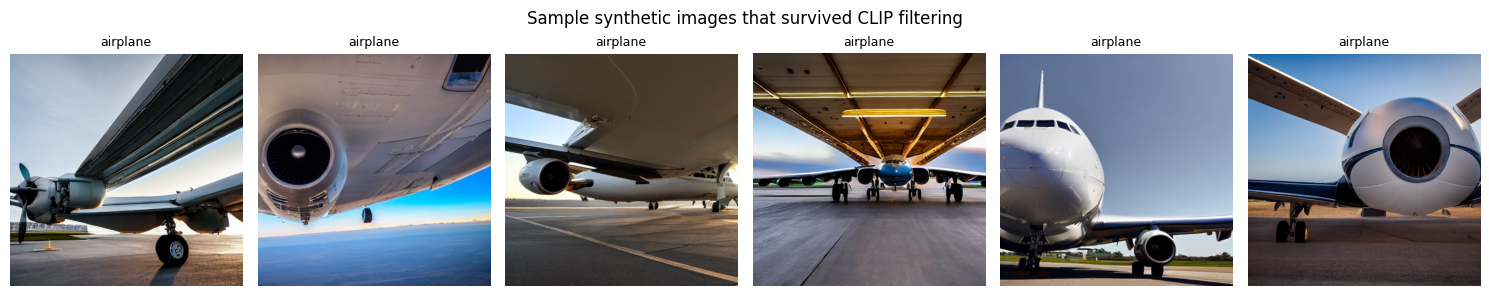

In [4]:
# ===========================================================================
# PART C — Synthetic data expansion pipeline
# ===========================================================================

SD_MODEL_ID = "runwayml/stable-diffusion-v1-5"


def load_text2img_pipeline(model_id=SD_MODEL_ID, device=None):
    device = device or DEVICE
    pipe = StableDiffusionPipeline.from_pretrained(
        model_id, torch_dtype=torch.float16 if device.type == "cuda" else torch.float32
    )
    pipe = pipe.to(device)
    pipe.set_progress_bar_config(disable=True)
    return pipe


@torch.no_grad()
def generate_text2img(pipe, class_names, n_per_class=8,
                       prompt_template="a photo of a {}, natural lighting, high detail",
                       negative_prompt="cartoon, drawing, low quality, blurry, text, watermark",
                       guidance_scale=7.5, num_inference_steps=30, seed=0):
    generator = torch.Generator(device=DEVICE).manual_seed(seed)
    synthetic = {}
    for cname in class_names:
        prompt = prompt_template.format(cname)
        images = pipe(
            prompt=[prompt] * n_per_class,
            negative_prompt=[negative_prompt] * n_per_class,
            guidance_scale=guidance_scale,
            num_inference_steps=num_inference_steps,
            generator=generator,
        ).images
        synthetic[cname] = images
        print(f"  generated {len(images)} synthetic images for class '{cname}'")
    return synthetic


def load_img2img_pipeline(model_id=SD_MODEL_ID, device=None):
    device = device or DEVICE
    pipe = StableDiffusionImg2ImgPipeline.from_pretrained(
        model_id, torch_dtype=torch.float16 if device.type == "cuda" else torch.float32
    )
    pipe = pipe.to(device)
    pipe.set_progress_bar_config(disable=True)
    return pipe


@torch.no_grad()
def generate_img2img_variations(pipe, real_images_by_class, n_variations_per_image=3,
                                 strength=0.35, guidance_scale=7.5, num_inference_steps=30,
                                 prompt_template="a photo of a {}, natural lighting, high detail",
                                 seed=0):
    generator = torch.Generator(device=DEVICE).manual_seed(seed)
    synthetic = {}
    for cname, images in real_images_by_class.items():
        prompt = prompt_template.format(cname)
        variations = []
        for img in images:
            img_resized = img.resize((512, 512))
            for _ in range(n_variations_per_image):
                out = pipe(
                    prompt=prompt,
                    image=img_resized,
                    strength=strength,
                    guidance_scale=guidance_scale,
                    num_inference_steps=num_inference_steps,
                    generator=generator,
                ).images[0]
                variations.append(out)
        synthetic[cname] = variations
        print(f"  generated {len(variations)} img2img variations for class '{cname}'")
    return synthetic


def classical_augmentation_fallback(real_images_by_class, n_variations_per_image=3, seed=0):
    aug = T.Compose([
        T.RandomResizedCrop(224, scale=(0.7, 1.0)),
        T.RandomHorizontalFlip(p=0.5),
        T.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    ])
    synthetic = {}
    for cname, images in real_images_by_class.items():
        variations = []
        for img in images:
            for _ in range(n_variations_per_image):
                variations.append(aug(img))
        synthetic[cname] = variations
    return synthetic


@torch.no_grad()
def clip_filter_synthetic(synthetic_by_class, class_names, keep_top_k=6,
                           prompt_template="a photo of a {}."):
    filtered = {}
    for cname in class_names:
        images = synthetic_by_class.get(cname, [])
        if not images:
            filtered[cname] = []
            continue
        prompt = prompt_template.format(cname)
        text_inputs = clip_processor(text=[prompt], return_tensors="pt", padding=True).to(DEVICE)
        text_feat = clip_model.get_text_features(**text_inputs)
        text_feat = _unwrap_embeds(text_feat)
        text_feat = F.normalize(text_feat, dim=-1)

        img_inputs = clip_processor(images=images, return_tensors="pt").to(DEVICE)
        img_feats = clip_model.get_image_features(**img_inputs)
        img_feats = _unwrap_embeds(img_feats)
        img_feats = F.normalize(img_feats, dim=-1)

        sims = (img_feats @ text_feat.T).squeeze(-1).cpu()
        keep_k = min(keep_top_k, len(images))
        top_idx = sims.topk(keep_k).indices.tolist()
        filtered[cname] = [images[i] for i in top_idx]
        print(f"  class '{cname}': kept {keep_k}/{len(images)} synthetic images "
              f"(similarity range kept: {sims[top_idx].min():.3f}-{sims[top_idx].max():.3f})")
    return filtered


@torch.no_grad()
def extract_features_from_pil_list(images, labels, batch_size=32):
    clip_feats, dino_feats = [], []
    for start in range(0, len(images), batch_size):
        batch_imgs = images[start:start + batch_size]

        clip_in = clip_processor(images=batch_imgs, return_tensors="pt").to(DEVICE)
        c_emb = clip_model.get_image_features(**clip_in)
        c_emb = _unwrap_embeds(c_emb)
        c_emb = F.normalize(c_emb, dim=-1)
        clip_feats.append(c_emb.cpu())

        dino_in = dino_processor(images=batch_imgs, return_tensors="pt").to(DEVICE)
        d_out = dino_model(**dino_in)
        d_emb = F.normalize(d_out.last_hidden_state[:, 0, :], dim=-1)
        dino_feats.append(d_emb.cpu())

    return torch.cat(clip_feats, dim=0), torch.cat(dino_feats, dim=0), torch.tensor(labels)


def run_expansion_demo(n_synth_per_class=8, keep_top_k=6, use_img2img=False, strength=0.35):
    class_names = CIFAR10_CLASSES

    if _HAS_DIFFUSERS:
        if use_img2img:
            real_by_class = {c: [] for c in class_names}
            for img, lab in train_subset:
                cname = class_names[lab]
                if len(real_by_class[cname]) < 4:
                    real_by_class[cname].append(img)
            print("Loading img2img pipeline (downloads checkpoint on first run)...")
            pipe = load_img2img_pipeline()
            print("Generating img2img variations from real support images...")
            synthetic = generate_img2img_variations(
                pipe, real_by_class, n_variations_per_image=max(1, n_synth_per_class // 4),
                strength=strength,
            )
        else:
            print("Loading text2img pipeline (downloads checkpoint on first run)...")
            pipe = load_text2img_pipeline()
            print("Generating text2img synthetic images...")
            synthetic = generate_text2img(pipe, class_names, n_per_class=n_synth_per_class)
    else:
        print("diffusers unavailable — using classical augmentation fallback instead of a diffusion model.")
        real_by_class = {c: [] for c in class_names}
        for img, lab in train_subset:
            cname = class_names[lab]
            real_by_class[cname].append(img)
        synthetic = classical_augmentation_fallback(real_by_class, n_variations_per_image=n_synth_per_class)

    print("\nFiltering synthetic images with CLIP self-similarity...")
    filtered = clip_filter_synthetic(synthetic, class_names, keep_top_k=keep_top_k)

    synth_images, synth_labels = [], []
    for ci, cname in enumerate(class_names):
        for img in filtered[cname]:
            synth_images.append(img)
            synth_labels.append(ci)

    if len(synth_images) == 0:
        print("No synthetic images survived filtering — try lowering keep_top_k or "
              "increasing n_synth_per_class.")
        return None

    print(f"\nExtracting CLIP+DINOv2 features for {len(synth_images)} surviving synthetic images...")
    synth_clip, synth_dino, synth_labels_t = extract_features_from_pil_list(synth_images, synth_labels)

    merged_clip = torch.cat([train_clip, synth_clip], dim=0)
    merged_dino = torch.cat([train_dino, synth_dino], dim=0)
    merged_labels = torch.cat([train_labels, synth_labels_t], dim=0)
    merged_concat = torch.cat([merged_clip, merged_dino], dim=-1)

    real_concat = torch.cat([train_clip, train_dino], dim=-1)
    test_concat = torch.cat([test_clip, test_dino], dim=-1)

    print("\nTraining fusion probe on REAL few-shot data only...")
    fusion_real = FusionHead(CLIP_DIM, DINO_DIM, COMMON_DIM).to(DEVICE)
    acc_real, _, _ = train_probe(real_concat, train_labels, test_concat, test_labels,
                                  in_dim=CLIP_DIM + DINO_DIM, backbone_module=fusion_real,
                                  epochs=400, lr=5e-3, weight_decay=1e-3)

    print("Training fusion probe on REAL + SYNTHETIC data...")
    fusion_expanded = FusionHead(CLIP_DIM, DINO_DIM, COMMON_DIM).to(DEVICE)
    acc_expanded, _, _ = train_probe(merged_concat, merged_labels, test_concat, test_labels,
                                      in_dim=CLIP_DIM + DINO_DIM, backbone_module=fusion_expanded,
                                      epochs=400, lr=5e-3, weight_decay=1e-3)

    print(f"\nFusion probe, real-only few-shot data:      {acc_real*100:.2f}%")
    print(f"Fusion probe, real + synthetic expansion:   {acc_expanded*100:.2f}%")
    print(f"Delta:                                       {(acc_expanded-acc_real)*100:+.2f} pts")

    fig, axes = plt.subplots(1, min(6, len(synth_images)), figsize=(15, 3))
    if len(synth_images) == 1:
        axes = [axes]
    for ax, img, lab in zip(axes, synth_images[:6], synth_labels[:6]):
        ax.imshow(img)
        ax.set_title(class_names[lab], fontsize=9)
        ax.axis("off")
    plt.suptitle("Sample synthetic images that survived CLIP filtering")
    plt.tight_layout()
    plt.show()

    return {"acc_real": acc_real, "acc_expanded": acc_expanded, "n_synthetic_kept": len(synth_images)}


if __name__ == "__main__":
    run_expansion_demo(n_synth_per_class=8, keep_top_k=6, use_img2img=False)
